# Multi-Input Electron Density Prediction with Attention GNN

This notebook extends the multi-input setup by replacing plain graph convolutions with attention-based message passing (GAT).

- Input: densities from previous `lookback` timesteps
- Output: density at `lookahead` timestep
- Graph: sequential + kNN edges
- Model: multi-head GAT with residual connections

In [2]:
# 1) Move to repo (if needed)
# If you have repo on GitHub:
# !git clone <your-repo-url>
# %cd /content/Predicting-Electron-Interactions-as-Evolving-Graphs/notebooks

# 2) Install dependencies
!pip -q install numpy pandas matplotlib seaborn scikit-learn tqdm scipy h5py

# PyTorch is usually preinstalled on Colab; install only if needed:
# !pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# PyG install matched to existing torch version
import torch, os
torch_ver = torch.__version__.split('+')[0]
cuda_tag = "cu121" if torch.cuda.is_available() else "cpu"
!pip -q install torch-geometric
!pip -q install pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html

print("Torch:", torch.__version__, "CUDA:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s eta 0:00:0000:01
ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib
Torch: 2.10.0+cu128 CUDA: True


In [1]:
print("Setup complete. You can now run the notebook cells.")

Setup complete. You can now run the notebook cells.


In [3]:
!nvidia-smi

Wed Mar 18 19:19:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv

# Enable memory efficient CUDA allocations
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')

PyTorch: 2.10.0+cu128
Device: cuda


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
print(os.path.exists('/content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw/ammonia_x'))
print(os.path.exists('/content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw/water_x'))

True
True


In [9]:
# Data path detection (works for local VS Code, Colab clone, or Drive mount)
# Defaulting to Google Drive path since Drive is mounted.
RAW_DATA_DIR = '/content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw'

def resolve_raw_data_dir():
    if RAW_DATA_DIR is not None:
        manual_path = Path(RAW_DATA_DIR)
        if (manual_path / 'ammonia_x').exists() and (manual_path / 'water_x').exists():
            return manual_path.resolve()
        raise FileNotFoundError(
            f'RAW_DATA_DIR is set but missing ammonia_x/water_x: {manual_path}'
        )

    candidates = [
        Path('../data/raw'),
        Path('./data/raw'),
        Path('/content/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw'),
        Path('/content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw'),
    ]

    for p in candidates:
        if (p / 'ammonia_x').exists() and (p / 'water_x').exists():
            return p.resolve()

    # Last fallback: search upward from current working directory.
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / 'data' / 'raw'
        if (candidate / 'ammonia_x').exists() and (candidate / 'water_x').exists():
            return candidate.resolve()

    raise FileNotFoundError(
        f'Could not find data/raw with ammonia_x and water_x from cwd={Path.cwd()}. '
        'In Colab, clone the repo or mount Drive and set RAW_DATA_DIR.'
    )

raw_data_dir = resolve_raw_data_dir()
ammonia_dir = raw_data_dir / 'ammonia_x'
water_dir = raw_data_dir / 'water_x'
print(f'Using data directory: {raw_data_dir}')

def load_density_file(filepath):
    """Load a single electron density file (2nd column)."""
    return np.loadtxt(filepath, usecols=1)

def get_all_timestep_files(directory):
    return sorted(glob.glob(str(directory / 'rvlab.tdscf.rho.*')))

ammonia_files = get_all_timestep_files(ammonia_dir)
water_files = get_all_timestep_files(water_dir)

print(f'Ammonia files: {len(ammonia_files)}')
print(f'Water files: {len(water_files)}')

assert len(ammonia_files) > 0, 'No ammonia files found. Check data path.'
assert len(water_files) > 0, 'No water files found. Check data path.'
sample_density = load_density_file(ammonia_files[0])
print(f'Grid points per sample: {len(sample_density)}')

Using data directory: /content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/data/raw
Ammonia files: 401
Water files: 401
Grid points per sample: 10540


In [10]:
def build_sequential_edges(num_nodes, k=5):
    edge_index = []
    for i in range(num_nodes):
        for j in range(max(0, i - k), min(num_nodes, i + k + 1)):
            if i != j:
                edge_index.append([i, j])
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

def build_knn_edges(features, k=10):
    # Use feature similarity graph over the current density snapshot.
    num_nodes = len(features)
    k = min(k, max(1, num_nodes - 1))

    nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto')
    nbrs.fit(features.reshape(-1, 1))
    _, indices = nbrs.kneighbors(features.reshape(-1, 1))

    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:
            edge_index.append([i, j])

    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

seq_edges = build_sequential_edges(len(sample_density), k=5)
knn_edges = build_knn_edges(sample_density, k=10)
print(f'Sequential edges: {seq_edges.shape}')
print(f'kNN edges: {knn_edges.shape}')

Sequential edges: torch.Size([2, 105370])
kNN edges: torch.Size([2, 105400])


In [11]:
class DensityGraphDataset(Dataset):
    """Multi-input dataset for single-future density prediction."""

    def __init__(self, density_files, lookback=3, lookahead=5, edge_type='both', k=10):
        super().__init__()
        self.density_files = density_files
        self.lookback = lookback
        self.lookahead = lookahead
        self.edge_type = edge_type
        self.k = k

        sample = load_density_file(density_files[0])
        self.num_nodes = len(sample)

    def len(self):
        return len(self.density_files) - self.lookback - self.lookahead + 1

    def get(self, idx):
        input_densities = []
        for i in range(idx, idx + self.lookback):
            input_densities.append(load_density_file(self.density_files[i]))

        target_idx = idx + self.lookback + self.lookahead - 1
        target_density = load_density_file(self.density_files[target_idx])

        x = torch.tensor(np.column_stack(input_densities), dtype=torch.float32)
        y = torch.tensor(target_density, dtype=torch.float32)

        if self.edge_type == 'sequential':
            edge_index = build_sequential_edges(self.num_nodes, k=self.k)
        elif self.edge_type == 'knn':
            edge_index = build_knn_edges(input_densities[-1], k=self.k)
        elif self.edge_type == 'both':
            edge_seq = build_sequential_edges(self.num_nodes, k=self.k)
            edge_knn = build_knn_edges(input_densities[-1], k=self.k)
            edge_index = torch.cat([edge_seq, edge_knn], dim=1)
        else:
            raise ValueError("edge_type must be one of: 'sequential', 'knn', 'both'")

        edge_index = torch.unique(edge_index, dim=1)
        return Data(x=x, edge_index=edge_index, y=y)

lookback = 3
lookahead = 5
dataset = DensityGraphDataset(
    ammonia_files,
    lookback=lookback,
    lookahead=lookahead,
    edge_type='both',
    k=3,
)

print(f'Dataset size: {len(dataset)}')
sample_data = dataset[0]
print(f'Sample x shape: {sample_data.x.shape}')
print(f'Sample y shape: {sample_data.y.shape}')
print(f'Sample edge_index shape: {sample_data.edge_index.shape}')

Dataset size: 394


Sample x shape: torch.Size([10540, 3])
Sample y shape: torch.Size([10540])
Sample edge_index shape: torch.Size([2, 91255])


In [12]:
class AttentionDensityGNN(nn.Module):
    """GAT-based model for multi-input density prediction."""

    def __init__(self, input_dim, hidden_dim=128, num_layers=4, heads=4, dropout=0.1):
        super().__init__()
        self.dropout = dropout

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.gat_layers = nn.ModuleList()
        self.norm_layers = nn.ModuleList()

        for layer_idx in range(num_layers):
            is_last = layer_idx == (num_layers - 1)
            out_channels = hidden_dim // heads if not is_last else hidden_dim
            concat = not is_last

            self.gat_layers.append(
                GATConv(
                    in_channels=hidden_dim,
                    out_channels=out_channels,
                    heads=heads,
                    concat=concat,
                    dropout=dropout,
                    add_self_loops=True,
                )
            )
            self.norm_layers.append(nn.LayerNorm(hidden_dim))

        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data, return_attention=False):
        x, edge_index = data.x, data.edge_index

        x = self.input_proj(x)
        x = F.relu(x)

        last_attention = None

        for gat, norm in zip(self.gat_layers, self.norm_layers):
            x_residual = x
            if return_attention:
                x, attn = gat(x, edge_index, return_attention_weights=True)
                last_attention = attn
            else:
                x = gat(x, edge_index)

            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            if x.shape == x_residual.shape:
                x = x + x_residual

        out = self.output_head(x).squeeze(-1)

        if return_attention:
            return out, last_attention
        return out

model = AttentionDensityGNN(
    input_dim=lookback,
    hidden_dim=80,
    num_layers=2,
    heads=2,
    dropout=0.1,
).to(device)

print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

AttentionDensityGNN(
  (input_proj): Linear(in_features=3, out_features=80, bias=True)
  (gat_layers): ModuleList(
    (0): GATConv(80, 40, heads=2)
    (1): GATConv(80, 80, heads=2)
  )
  (norm_layers): ModuleList(
    (0-1): 2 x LayerNorm((80,), eps=1e-05, elementwise_affine=True)
  )
  (output_head): Sequential(
    (0): Linear(in_features=80, out_features=40, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=40, out_features=1, bias=True)
  )
)
Total parameters: 23,761


In [13]:
train_size = int(0.8 * len(dataset))
train_dataset = [dataset[i] for i in range(train_size)]
val_dataset = [dataset[i] for i in range(train_size, len(dataset))]

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)
criterion = nn.MSELoss()

print(f'Train samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')

Train samples: 315
Validation samples: 79


In [14]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch)
        loss = criterion(pred, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        
        # Clear cache after each batch to prevent fragmentation
        torch.cuda.empty_cache()

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        loss = criterion(pred, batch.y)
        total_loss += loss.item() * batch.num_graphs
        torch.cuda.empty_cache()

    return total_loss / len(loader.dataset)

num_epochs = 50
train_losses, val_losses = [], []
best_val_loss = float('inf')

# Save checkpoints to Drive on Colab, fallback to local models folder otherwise.
drive_models_dir = Path('/content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/models')
local_models_dir = Path('../models').resolve()
save_dir = drive_models_dir if drive_models_dir.parent.exists() else local_models_dir
save_dir.mkdir(parents=True, exist_ok=True)
best_model_path = str(save_dir / 'best_density_gnn_attention_multi_input.pt')
print(f'Checkpoint save path: {best_model_path}')

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    # Clear GPU cache to prevent memory fragmentation
    torch.cuda.empty_cache()

    if (epoch + 1) % 5 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch + 1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr:.6f}')

print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val_loss:.6f}')

Checkpoint save path: /content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/models/best_density_gnn_attention_multi_input.pt
Epoch   5 | Train: 13.542085 | Val: 0.131893 | LR: 0.001000
Epoch  10 | Train: 13.398895 | Val: 0.460317 | LR: 0.001000
Epoch  15 | Train: 13.324658 | Val: 0.273333 | LR: 0.000500
Epoch  20 | Train: 13.278959 | Val: 0.110044 | LR: 0.000500
Epoch  25 | Train: 13.111606 | Val: 0.012540 | LR: 0.000500
Epoch  30 | Train: 13.123987 | Val: 0.122748 | LR: 0.000250
Epoch  35 | Train: 13.013176 | Val: 0.124028 | LR: 0.000250
Epoch  40 | Train: 12.112780 | Val: 0.020890 | LR: 0.000250
Epoch  45 | Train: 12.087616 | Val: 0.078910 | LR: 0.000125
Epoch  50 | Train: 12.051922 | Val: 0.025634 | LR: 0.000125
Saved best model: /content/drive/MyDrive/Predicting-Electron-Interactions-as-Evolving-Graphs/models/best_density_gnn_attention_multi_input.pt
Best validation loss: 0.000535


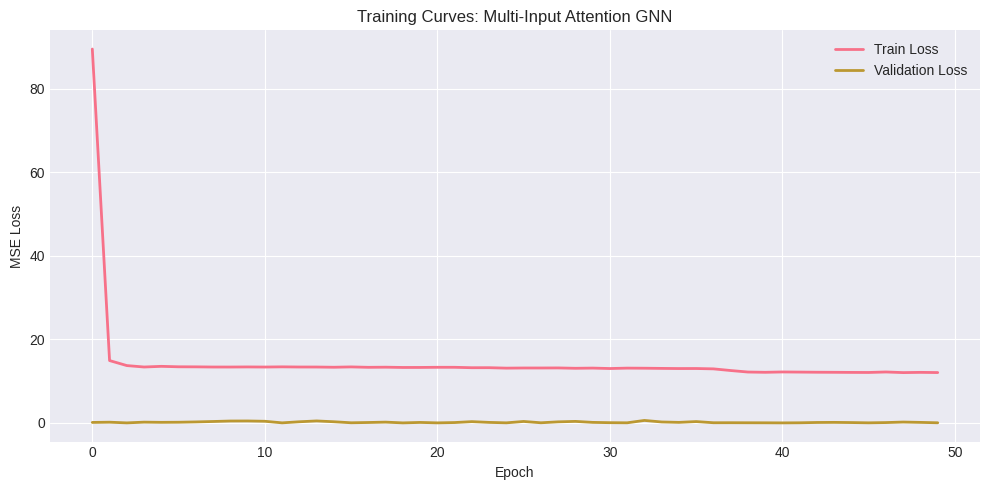

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Curves: Multi-Input Attention GNN')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = model(batch)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(batch.y.cpu().numpy())

predictions = np.concatenate(all_preds)
targets = np.concatenate(all_targets)

mse = np.mean((predictions - targets) ** 2)
mae = np.mean(np.abs(predictions - targets))
den = np.sum((targets - targets.mean()) ** 2)
r2 = 1.0 - (np.sum((targets - predictions) ** 2) / den if den > 0 else 0.0)

print('Validation metrics:')
print(f'  MSE: {mse:.6f}')
print(f'  MAE: {mae:.6f}')
print(f'  R2 : {r2:.6f}')

Validation metrics:
  MSE: 0.000535
  MAE: 0.012237
  R2 : 1.000000


In [17]:
# Inspect attention weights from one validation graph.
sample_batch = val_dataset[0].to(device)
sample_pred, attention_info = model(sample_batch, return_attention=True)
attn_edge_index, attn_weights = attention_info

# Average over attention heads for readability.
attn_mean = attn_weights.mean(dim=1).detach().cpu().numpy()

top_k = min(20, len(attn_mean))
top_idx = np.argsort(attn_mean)[-top_k:][::-1]

print(f'Attention tensor shape: {attn_weights.shape}')
print(f'Top {top_k} attended edges (src -> dst, score):')
for idx in top_idx:
    src = int(attn_edge_index[0, idx].item())
    dst = int(attn_edge_index[1, idx].item())
    print(f'  {src:6d} -> {dst:6d} : {attn_mean[idx]:.6f}')

Attention tensor shape: torch.Size([101991, 2])
Top 20 attended edges (src -> dst, score):
     566 ->    563 : 0.603260
     580 ->    577 : 0.603001
     552 ->    549 : 0.602040
     594 ->    591 : 0.601127
     538 ->    535 : 0.599918
     524 ->    521 : 0.597457
     510 ->    507 : 0.594812
     622 ->    619 : 0.593319
     496 ->    493 : 0.591696
     482 ->    479 : 0.587584
     636 ->    633 : 0.587380
     468 ->    465 : 0.581866
     608 ->    605 : 0.578717
     650 ->    647 : 0.578700
     676 ->    673 : 0.574180
     454 ->    451 : 0.573872
    4356 ->    594 : 0.573190
     440 ->    437 : 0.563027
     384 ->    381 : 0.551204
     426 ->    423 : 0.549534
